# Reinforcement Learning Game Design: Deep Q-Learning Snake
## 1. Environment Setup and Imports
This section imports the necessary libraries. 
* `pygame` is used to construct the graphical user interface and game environment.
* `torch` (PyTorch) is used to build and train the Deep Q-Network.
* `matplotlib` is used to visualize the training metrics, demonstrating the agent's learning progress over time.

In [6]:
import pygame
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from collections import deque

# Initialize Pygame and Font
pygame.init()
pygame.font.init()
font_title = pygame.font.SysFont('arial', 28, bold=True)
font_body = pygame.font.SysFont('arial', 20)

# Game Constants
GAME_WIDTH = 640  
PANEL_WIDTH = 260 
WINDOW_WIDTH = GAME_WIDTH + PANEL_WIDTH
WINDOW_HEIGHT = 480
BLOCK_SIZE = 20
SPEED = 15


# Colors
BLACK = (10, 10, 15)           # Game background
PANEL_BG = (30, 35, 50)        # Panel background (Dark Blue/Gray)
WHITE = (255, 255, 255)
TEXT_COLOR = (200, 210, 230)
RED = (230, 80, 80)            # Food / Negative Reward text
GREEN1 = (50, 200, 100)        # Snake outer
GREEN2 = (30, 150, 70)         # Snake inner
PURPLE = (180, 100, 220)       # Poison
GRAY = (70, 75, 90)            # Walls

## 2. Game Environment and MDP Formulation
This class defines the Markov Decision Process (MDP) with a multi-object environment, including walls and poison traps.
* **State Space (15 Dimensions):** Clearly defined state space comprising:
  - Danger sensors (3D): Detects walls, the agent's body, and poison traps one step ahead.
  - Current direction (4D).
  - Relative food location (4D).
  - Relative poison location (4D).
* **Action Space:** 3 discrete actions `[Straight, Turn Right, Turn Left]`.
* **Reward Function:** Implements positive/negative rewards. +10 for eating food, -10 for dying (hitting a wall, body, or poison). Reward shaping (+1/-1) is applied based on distance to the food to guide the agent efficiently.

In [ ]:
class SnakeGameAI:
    def __init__(self):
        self.display = pygame.display.set_mode((WINDOW_WIDTH, WINDOW_HEIGHT))
        pygame.display.set_caption('Deep Q-Learning Agent Dashboard')
        self.clock = pygame.time.Clock()
        self.reset()

    def reset(self):
        self.direction = (1, 0) 
        self.head = [GAME_WIDTH // 2, WINDOW_HEIGHT // 2]
        self.snake = [self.head.copy(), 
                      [self.head[0] - BLOCK_SIZE, self.head[1]],
                      [self.head[0] - (2 * BLOCK_SIZE), self.head[1]]]
        self.score = 0
        self.food = None
        self.poison = None
        self._place_items()
        self.frame_iteration = 0
        return self.get_state()

    def _place_items(self):
        min_pos = BLOCK_SIZE
        max_x = GAME_WIDTH - 2 * BLOCK_SIZE
        max_y = WINDOW_HEIGHT - 2 * BLOCK_SIZE

        # Food
        x_food = random.randint(min_pos // BLOCK_SIZE, max_x // BLOCK_SIZE) * BLOCK_SIZE
        y_food = random.randint(min_pos // BLOCK_SIZE, max_y // BLOCK_SIZE) * BLOCK_SIZE
        self.food = [x_food, y_food]
        if self.food in self.snake:
            self._place_items()
            return
            
        # Poison
        x_poison = random.randint(min_pos // BLOCK_SIZE, max_x // BLOCK_SIZE) * BLOCK_SIZE
        y_poison = random.randint(min_pos // BLOCK_SIZE, max_y // BLOCK_SIZE) * BLOCK_SIZE
        self.poison = [x_poison, y_poison]
        if self.poison in self.snake or self.poison == self.food:
            self._place_items() 

    def get_state(self):
        head = self.snake[0]
        point_l = [head[0] - BLOCK_SIZE, head[1]]
        point_r = [head[0] + BLOCK_SIZE, head[1]]
        point_u = [head[0], head[1] - BLOCK_SIZE]
        point_d = [head[0], head[1] + BLOCK_SIZE]
        
        dir_l = self.direction == (-1, 0)
        dir_r = self.direction == (1, 0)
        dir_u = self.direction == (0, -1)
        dir_d = self.direction == (0, 1)

        state = [
            (dir_r and self.is_collision(point_r)) or (dir_l and self.is_collision(point_l)) or (dir_u and self.is_collision(point_u)) or (dir_d and self.is_collision(point_d)),
            (dir_u and self.is_collision(point_r)) or (dir_d and self.is_collision(point_l)) or (dir_l and self.is_collision(point_u)) or (dir_r and self.is_collision(point_d)),
            (dir_d and self.is_collision(point_r)) or (dir_u and self.is_collision(point_l)) or (dir_r and self.is_collision(point_u)) or (dir_l and self.is_collision(point_d)),
            dir_l, dir_r, dir_u, dir_d,
            self.food[0] < self.head[0], self.food[0] > self.head[0], self.food[1] < self.head[1], self.food[1] > self.head[1],  
            self.poison[0] < self.head[0], self.poison[0] > self.head[0], self.poison[1] < self.head[1], self.poison[1] > self.head[1] 
        ]
        return np.array(state, dtype=int)

    def is_collision(self, pt=None):
        if pt is None:
            pt = self.head
        if pt[0] >= GAME_WIDTH - BLOCK_SIZE or pt[0] < BLOCK_SIZE or pt[1] >= WINDOW_HEIGHT - BLOCK_SIZE or pt[1] < BLOCK_SIZE:
            return True
        if pt in self.snake[1:]:
            return True
        if pt == self.poison:
            return True
        return False

    def play_step(self, action, episode=0, epsilon=0.0, max_q=0.0, total_reward=0.0):
        self.frame_iteration += 1
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                quit()

        old_dist = abs(self.head[0] - self.food[0]) + abs(self.head[1] - self.food[1])
        clock_wise = [(1,0), (0,1), (-1,0), (0,-1)]
        idx = clock_wise.index(self.direction)
        
        action_text = "STRAIGHT"
        if action == 1: 
            self.direction = clock_wise[(idx + 1) % 4]
            action_text = "TURN RIGHT"
        elif action == 2: 
            self.direction = clock_wise[(idx - 1) % 4]
            action_text = "TURN LEFT"
            
        self.head = [self.head[0] + self.direction[0] * BLOCK_SIZE, self.head[1] + self.direction[1] * BLOCK_SIZE]
        self.snake.insert(0, self.head.copy())
        
        reward = 0
        game_over = False
        
        if self.is_collision() or self.frame_iteration > 100 * len(self.snake):
            game_over = True
            reward = -10
            self._update_ui(action_text, reward, episode, epsilon, max_q, total_reward)
            return self.get_state(), reward, game_over, self.score

        if self.head == self.food:
            self.score += 1
            reward = 10 
            self._place_items() 
        else:
            self.snake.pop() 
            new_dist = abs(self.head[0] - self.food[0]) + abs(self.head[1] - self.food[1])
            if new_dist < old_dist:
                reward = 1
            else:
                reward = -1

        self._update_ui(action_text, reward, episode, epsilon, max_q, total_reward)
        self.clock.tick(SPEED)
        return self.get_state(), reward, game_over, self.score

    def _update_ui(self, action_text, reward, episode, epsilon, max_q, total_reward):
        self.display.fill(BLACK) 
        
        pygame.draw.rect(self.display, PANEL_BG, pygame.Rect(GAME_WIDTH, 0, PANEL_WIDTH, WINDOW_HEIGHT))
        pygame.draw.line(self.display, GRAY, (GAME_WIDTH, 0), (GAME_WIDTH, WINDOW_HEIGHT), 2)
        
        pygame.draw.rect(self.display, GRAY, pygame.Rect(0, 0, GAME_WIDTH, BLOCK_SIZE)) # Top
        pygame.draw.rect(self.display, GRAY, pygame.Rect(0, WINDOW_HEIGHT - BLOCK_SIZE, GAME_WIDTH, BLOCK_SIZE)) # Bottom
        pygame.draw.rect(self.display, GRAY, pygame.Rect(0, 0, BLOCK_SIZE, WINDOW_HEIGHT)) # Left
        pygame.draw.rect(self.display, GRAY, pygame.Rect(GAME_WIDTH - BLOCK_SIZE, 0, BLOCK_SIZE, WINDOW_HEIGHT)) # Right
        
        for pt in self.snake:
            pygame.draw.rect(self.display, GREEN1, pygame.Rect(pt[0], pt[1], BLOCK_SIZE, BLOCK_SIZE))
            pygame.draw.rect(self.display, GREEN2, pygame.Rect(pt[0]+4, pt[1]+4, 12, 12)) 
            
        pygame.draw.rect(self.display, RED, pygame.Rect(self.food[0], self.food[1], BLOCK_SIZE, BLOCK_SIZE))
        pygame.draw.rect(self.display, PURPLE, pygame.Rect(self.poison[0], self.poison[1], BLOCK_SIZE, BLOCK_SIZE))

        pad_x = GAME_WIDTH + 20
        
        # Section A: Status
        title1 = font_title.render("Status", True, WHITE)
        self.display.blit(title1, [pad_x, 20])
        
        rew_color = GREEN1 if total_reward > 0 else RED if total_reward < 0 else TEXT_COLOR
        txt_total_rew = font_body.render(f"Total Reward : {total_reward:.1f}", True, rew_color)
        txt_step_rew = font_body.render(f"Step Reward : {reward}", True, TEXT_COLOR)
        txt_score = font_body.render(f"Food Eaten : {self.score}", True, TEXT_COLOR)
        txt_steps = font_body.render(f"Steps Alive : {self.frame_iteration}", True, TEXT_COLOR)
        txt_action = font_body.render(f"Action : {action_text}", True, WHITE)
        
        self.display.blit(txt_total_rew, [pad_x, 60])
        self.display.blit(txt_step_rew, [pad_x, 90])
        self.display.blit(txt_score, [pad_x, 120])
        self.display.blit(txt_steps, [pad_x, 150])
        self.display.blit(txt_action, [pad_x, 180])
        
        pygame.draw.line(self.display, GRAY, (pad_x, 230), (WINDOW_WIDTH - 20, 230), 2)
        
        # Section B: Training Monitor
        title2 = font_title.render("Training Monitor", True, WHITE)
        self.display.blit(title2, [pad_x, 250])
        
        txt_episode = font_body.render(f"Episode : {episode}", True, TEXT_COLOR)
        txt_epsilon = font_body.render(f"Epsilon : {epsilon:.4f}", True, TEXT_COLOR)
        txt_maxq = font_body.render(f"Q(s) max : {max_q:.2f}", True, TEXT_COLOR)
        
        self.display.blit(txt_episode, [pad_x, 290])
        self.display.blit(txt_epsilon, [pad_x, 320])
        self.display.blit(txt_maxq, [pad_x, 350])
        
        pygame.display.flip()

## 3. Deep Q-Network (DQN) Architecture
This implements the Q-learning algorithm using a deep neural network[cite: 10, 11, 26]. The network takes a 15-dimensional state as input and outputs the Q-values for the 3 possible actions.

In [8]:
class Linear_QNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # Input size is 15 to accommodate the enhanced state space
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = F.relu(self.linear1(x))
        x = self.linear2(x)
        return x

## 4. Q-Learning Training Loop and Visualization
This section manages the core training loop. It utilizes an epsilon-greedy strategy to balance exploration and exploitation, and uses a discount factor (gamma) to maximize cumulative reward over time. The performance is evaluated through a live-updating matplotlib chart.

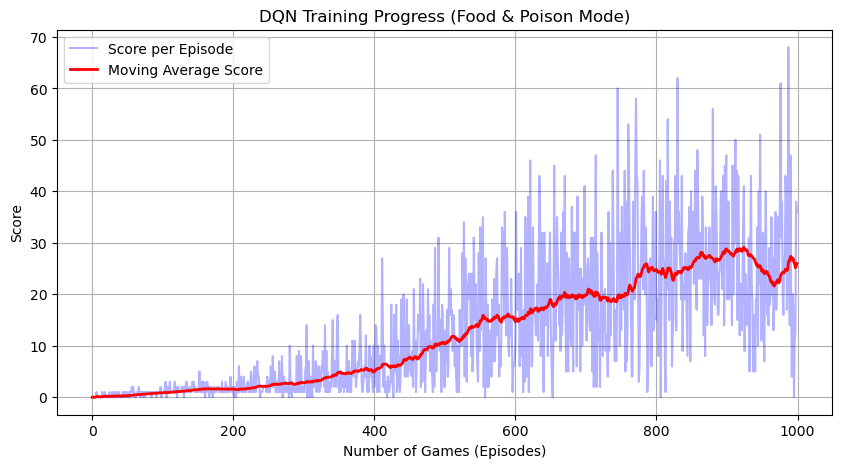

Episode: 999 | Score: 36 | Record: 68 | Epsilon: 0.01


In [11]:
def plot_metrics(scores, mean_scores):
    """Helper function to visualize training progress."""
    clear_output(wait=True)
    plt.figure(figsize=(10, 5))
    plt.title('DQN Training Progress (Food & Poison Mode)')
    plt.xlabel('Number of Games (Episodes)')
    plt.ylabel('Score')
    plt.plot(scores, label='Score per Episode', color='blue', alpha=0.3)
    plt.plot(mean_scores, label='Moving Average Score', color='red', linewidth=2)
    plt.legend()
    plt.grid(True)
    plt.show()

def train():
    plot_scores = []
    plot_mean_scores = []
    total_score = 0
    record = 0
    
    env = SnakeGameAI()
    model = Linear_QNet(15, 256, 3) 
    optimizer = optim.Adam(model.parameters(), lr=0.001) 
    criterion = nn.MSELoss()
    memory = deque(maxlen=100000)
    
    batch_size = 1000
    gamma = 0.9 
    epsilon = 1.0 
    epsilon_min = 0.01
    epsilon_decay = 0.995
    
    episodes = 1000
    
    for episode in range(episodes):
        state = env.reset()
        done = False
        cumulative_reward = 0.0 
        global SPEED
        if episode > 950:  
            SPEED = 15
        else:
            SPEED = 1000
        while not done:
            state_tensor = torch.tensor(state, dtype=torch.float)
            
            with torch.no_grad():
                prediction = model(state_tensor)
                max_q_value = torch.max(prediction).item()
            
            # Epsilon-Greedy
            if random.random() < epsilon:
                action = random.randint(0, 2)
            else:
                action = torch.argmax(prediction).item() 
                
            next_state, reward, done, score = env.play_step(
                action=action, 
                episode=episode, 
                epsilon=epsilon, 
                max_q=max_q_value, 
                total_reward=cumulative_reward
            )
            
            cumulative_reward += reward
            memory.append((state, action, reward, next_state, done))
            state = next_state
            
            if len(memory) > batch_size:
                mini_batch = random.sample(memory, batch_size)
                states, actions, rewards, next_states, dones = zip(*mini_batch)
                
                states = torch.tensor(np.array(states), dtype=torch.float)
                actions = torch.tensor(actions, dtype=torch.long).unsqueeze(1)
                rewards = torch.tensor(rewards, dtype=torch.float)
                next_states = torch.tensor(np.array(next_states), dtype=torch.float)
                dones = torch.tensor(dones, dtype=torch.float)
                
                curr_q = model(states).gather(1, actions).squeeze()
                next_q = model(next_states).max(1)[0]
                target_q = rewards + gamma * next_q * (1 - dones)
                
                loss = criterion(curr_q, target_q.detach())
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        if epsilon > epsilon_min:
            epsilon *= epsilon_decay
            
        if score > record:
            record = score
            
        plot_scores.append(score)
        total_score += score
        mean_score = sum(plot_scores[-50:]) / len(plot_scores[-50:])
        plot_mean_scores.append(mean_score)
        
        if episode % 5 == 0 or episode == episodes - 1:
            plot_metrics(plot_scores, plot_mean_scores)
            print(f'Episode: {episode} | Score: {score} | Record: {record} | Epsilon: {epsilon:.2f}')

    pygame.quit()

if __name__ == '__main__':
    train()